In [1]:
# Do not forget: $ poetry run jupyter notebook

%matplotlib inline
%reload_ext autoreload
%autoreload 2

import torch
DEVICE = torch.device('cpu')

# NAME = 'ladle_furnace_inference'

# **Inference: NN to estimate scattering**

## **Building scenarios with different detector configurations**

We will begin by defining 4 scenarios with different detector configurations. Each scenario corresponds to a **volume**, consisting of the configured **detectors** and a **passive volume**. 

In [2]:
from tomopt.volume import Volume
from tomopt.benchmarks.ladle_furnace import get_detector

In [3]:
# Panel span [cm]
PanelSpan = 0.7
#PanelSpan = 0.9

# muon hit detection resolution [m]
Resolution = 0.00001 # 0,01 mm (really high resolution)

PanelZ = [1.80, 1.65, 1.50, 0.30, 0.15, 0.00] # Big gap

volume_BigGapHighRes = Volume(get_detector(device=DEVICE, span=PanelSpan, res=Resolution, panelZpositions=PanelZ), budget=6)
volume_BigGapHighRes

# muon hit detection resolution [m]
Resolution = 0.001 # 1 mm (common muography detector)

volume_BigGap = Volume(get_detector(device=DEVICE, span=PanelSpan, res=Resolution, panelZpositions=PanelZ), budget=6)
volume_BigGap

PanelZ = [1.60, 1.55, 1.50, 0.30, 0.25, 0.20] # Small gap

volume_SmallGap = Volume(get_detector(device=DEVICE, span=PanelSpan, res=Resolution, panelZpositions=PanelZ), budget=6)
volume_SmallGap

PanelZ = [1.60, 1.55, 1.50, 0.30, 0.15, 0.00] # Not centred

volume_NotCentred = Volume(get_detector(device=DEVICE, span=PanelSpan, res=Resolution, panelZpositions=PanelZ), budget=6)
volume_NotCentred


Volume(
  (layers): ModuleList(
    (0): PanelDetectorLayer(
      (panels): ModuleList(
        (0): <class 'tomopt.volume.panel.SigmoidDetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([1.6000]), and xy span tensor([1., 1.]) with budget scale 1.4285714626312256
        (1): <class 'tomopt.volume.panel.SigmoidDetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([1.5500]), and xy span tensor([1., 1.]) with budget scale 1.4285714626312256
        (2): <class 'tomopt.volume.panel.SigmoidDetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([1.5000]), and xy span tensor([1., 1.]) with budget scale 1.4285714626312256
      )
    )
    (1): PassiveLayer located at z=tensor([1.4000])
    (2): PassiveLayer located at z=tensor([1.3000])
    (3): PassiveLayer located at z=tensor([1.2000])
    (4): PassiveLayer located at z=tensor([1.1000])
    (5): PassiveLayer located at z=tensor([1.])
    (6): PassiveLayer located at z=tensor([0.9000])
    (7): PassiveLay

In [4]:
volume_BigGap.layers[0]

PanelDetectorLayer(
  (panels): ModuleList(
    (0): <class 'tomopt.volume.panel.SigmoidDetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([1.8000]), and xy span tensor([1., 1.]) with budget scale 1.4285714626312256
    (1): <class 'tomopt.volume.panel.SigmoidDetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([1.6500]), and xy span tensor([1., 1.]) with budget scale 1.4285714626312256
    (2): <class 'tomopt.volume.panel.SigmoidDetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([1.5000]), and xy span tensor([1., 1.]) with budget scale 1.4285714626312256
  )
)

We can visualise the layout of this in 3D.

#### a) Big gap detection panels

In [5]:
# To do: Specify panel span in .draw method

<IPython.core.display.Javascript object>


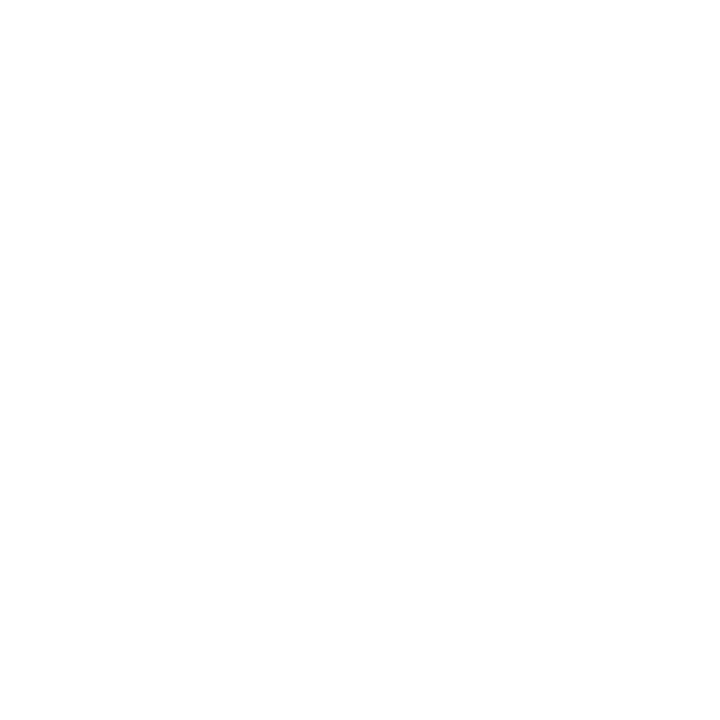

In [6]:
%matplotlib notebook
volume_BigGap.draw(xlim=(-0.5,1.5), ylim=(-0.5,1.5), zlim=(-0.5,1.5))

#### b) Small gap detection panels

<IPython.core.display.Javascript object>


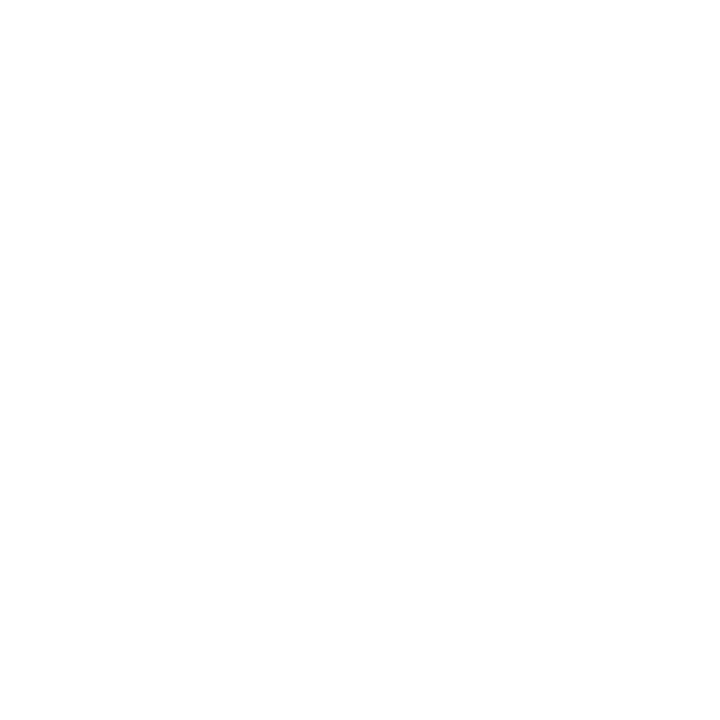

In [7]:
%matplotlib notebook
volume_SmallGap.draw(xlim=(-0.5,1.5), ylim=(-0.5,1.5), zlim=(-0.5,1.5))

#### c) Not centred detection panels

<IPython.core.display.Javascript object>


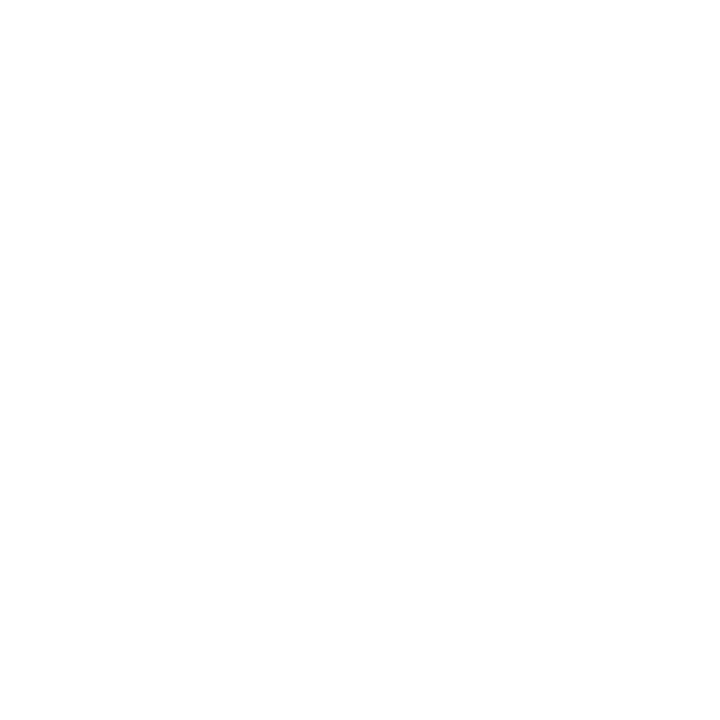

In [8]:
%matplotlib notebook
volume_NotCentred.draw(xlim=(-0.5,1.5), ylim=(-0.5,1.5), zlim=(-0.5,1.5))

In [9]:
%matplotlib inline

## **Choose scenario and define number of simulations and muon flux**

We'll continue defining the **number of simulations** we want to produce, their individual **data taking time**, and the considered **flux of muons**.

In [271]:
Simulations = 80 # number of simulations
Simulations = 800 # number of simulations
Time = 0.1 # muography measurement time of a single simulation [min]
Flux = 6845 # considered flux of muons [muons/(min*m^2)]

# TO DO: Use generic random scenarions

# Choose scenario
Scenario = "BigGapHighRes"
# Scenario = "BigGap"
# Scenario = "SmallGap"
# Scenario = "NotCentred"

## **Generate passive volumes**

Now we'll need to define how to **generate** example **passive volumes**. The furnace ladle is made of several elements:

 - **Ladle**: a $1\times1\times1 \:[\text{m}^3]$ bucket made of solid steel.

 - **Liquid steel**: The ladle is filled with a **random amount** of liquid steel.

 - **Slag**: Above the liquid steel is a **layer** of **slag**, with a lower density that liquid steel.

 - **Air**: The rest of the ladle is filled with air.


`LadleFurnacePassiveGenerator` class will create layouts based on varying fill-heights of a furnace ladle, with varying levels of slag.

In [6]:
import torch
from torch import Tensor

In [8]:
def arb_rad_length(*,z:float, lw:Tensor, size:float) -> Tensor:
    #rad_length = torch.ones(list((lw/size).long()))
    rad_length = torch.rand(list((lw/size).long()))*10
    return rad_length

In [16]:
from tomopt.volume import DetectorPanel

In [17]:
panel = DetectorPanel(res=1e3, eff=0.5, init_xyz=[0.5,0.5,0.9], init_xy_span=[0.5,0.5], m2_cost=1)
panel

<class 'tomopt.volume.panel.DetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([0.9000]), and xy span tensor([0.5000, 0.5000]) with budget scale tensor([1.])

In [18]:
from tomopt.volume import PanelDetectorLayer

In [19]:
dl = PanelDetectorLayer(pos='above', lw=Tensor([1,1]), z=1, size=2*0.1,
                        panels=[DetectorPanel(res=1e3, eff=0.5,
                                              init_xyz=[0.5,0.5,1-(i*(2*0.1)/4)],
                                              init_xy_span=[1.0,1.0]) for i in range(4)])
dl

PanelDetectorLayer(
  (panels): ModuleList(
    (0): <class 'tomopt.volume.panel.DetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([1.]), and xy span tensor([1., 1.]) with budget scale tensor([1.])
    (1): <class 'tomopt.volume.panel.DetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([0.9500]), and xy span tensor([1., 1.]) with budget scale tensor([1.])
    (2): <class 'tomopt.volume.panel.DetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([0.9000]), and xy span tensor([1., 1.]) with budget scale tensor([1.])
    (3): <class 'tomopt.volume.panel.DetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([0.8500]), and xy span tensor([1., 1.]) with budget scale tensor([1.])
  )
)

In [20]:
from tomopt.volume import PassiveLayer

In [21]:
pl = PassiveLayer(rad_length_func=arb_rad_length, lw=Tensor([1,1]), z=0.2, size=0.1)

In [22]:
# Random generator

import numpy as np
from torch import nn

def get_layers():
    layers = []
    lwh = Tensor([1,1,1])
    size = 0.1
    init_eff = 0.5
    init_res = 1000
    n_panels = 4
    layers.append(PanelDetectorLayer(pos='above', lw=lwh[:2], z=1, size=2*size,
                                     panels=[DetectorPanel(res=init_res, eff=init_eff,
                                                      init_xyz=[0.5,0.5,1-(i*(2*size)/n_panels)], init_xy_span=[1.0,1.0]) for i in range(n_panels)]))
    for z in [0.8,0.7,0.6,0.5,0.4,0.3]:
        layers.append(PassiveLayer(rad_length_func=arb_rad_length, lw=lwh[:2], z=z, size=size))
    layers.append(PanelDetectorLayer(pos='below', lw=lwh[:2], z=0.2, size=2*size,
                                     panels=[DetectorPanel(res=init_res, eff=init_eff,
                                                      init_xyz=[0.5,0.5,0.2-(i*(2*size)/n_panels)], init_xy_span=[1.0,1.0]) for i in range(n_panels)]))

    return nn.ModuleList(layers) 

In [23]:
get_layers()

ModuleList(
  (0): PanelDetectorLayer(
    (panels): ModuleList(
      (0): <class 'tomopt.volume.panel.DetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([1.]), and xy span tensor([1., 1.]) with budget scale tensor([1.])
      (1): <class 'tomopt.volume.panel.DetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([0.9500]), and xy span tensor([1., 1.]) with budget scale tensor([1.])
      (2): <class 'tomopt.volume.panel.DetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([0.9000]), and xy span tensor([1., 1.]) with budget scale tensor([1.])
      (3): <class 'tomopt.volume.panel.DetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([0.8500]), and xy span tensor([1., 1.]) with budget scale tensor([1.])
    )
  )
  (1): PassiveLayer located at z=tensor([0.8000])
  (2): PassiveLayer located at z=tensor([0.7000])
  (3): PassiveLayer located at z=tensor([0.6000])
  (4): PassiveLayer located at z=tensor([0.5000])
  (5): PassiveLayer located a

In [11]:
from tomopt.benchmarks.ladle_furnace import LadleFurnacePassiveGenerator

In [272]:
if Scenario=="BigGapHighRes":
    volume=volume_BigGapHighRes
if Scenario=="BigGap":
    volume=volume_BigGap
if Scenario=="SmallGap":
    volume=volume_SmallGap
if Scenario=="NotCentred":
    volume=volume_NotCentred


print(volume)
# volume.get_detectors(), volume.get_passives()

passive_gen = LadleFurnacePassiveGenerator(volume)

Volume(
  (layers): ModuleList(
    (0): PanelDetectorLayer(
      (panels): ModuleList(
        (0): <class 'tomopt.volume.panel.SigmoidDetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([1.8000]), and xy span tensor([1., 1.]) with budget scale 1.4285714626312256
        (1): <class 'tomopt.volume.panel.SigmoidDetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([1.6500]), and xy span tensor([1., 1.]) with budget scale 1.4285714626312256
        (2): <class 'tomopt.volume.panel.SigmoidDetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([1.5000]), and xy span tensor([1., 1.]) with budget scale 1.4285714626312256
      )
    )
    (1): PassiveLayer located at z=tensor([1.4000])
    (2): PassiveLayer located at z=tensor([1.3000])
    (3): PassiveLayer located at z=tensor([1.2000])
    (4): PassiveLayer located at z=tensor([1.1000])
    (5): PassiveLayer located at z=tensor([1.])
    (6): PassiveLayer located at z=tensor([0.9000])
    (7): PassiveLay

We'll generate 10 volumes at a every fill-height. The 10cm of slag will be present for ever volume.

In [273]:
HEIGHTS = [0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3]
N_PASSIVES_PER_H = int(Simulations/len(HEIGHTS))

from tomopt.optimisation import PassiveYielder

trn_passives = PassiveYielder([passive_gen._generate(fixed_mat_z=h, fixed_slag_z=h+0.1)
                               for _ in range(N_PASSIVES_PER_H) for h in HEIGHTS])

## Just one
#h = 1.3
#trn_passives = PassiveYielder([passive_gen._generate(fixed_mat_z=h, fixed_slag_z=h+0.1)])

This is the amount of passive volumes generated.

In [274]:
len(HEIGHTS), N_PASSIVES_PER_H, len(trn_passives)

(8, 100, 800)

Let's visualise one of these volume layouts by repurposing one of the visualisers in TomOpt

In [275]:
SelectedVolume = 10
f,t = trn_passives.passives[SelectedVolume]
volume.load_rad_length(f, t)

In [276]:
# Get X0 of all voxels
x0 = volume.get_rad_cube()
x0.shape, x0

(torch.Size([10, 10, 10]),
 tensor([[[1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02,
           1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02],
          [1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02,
           1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02],
          [1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02,
           1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02],
          [1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02,
           1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02],
          [1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02,
           1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02],
          [1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02,
           1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02],
          [1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02,
           1.7820e-02, 1.7820e-02, 1.7820e-0

In [17]:
from tomopt.plotting import plot_pred_true_x0
from tomopt.utils import x0targs_to_classtargs
from tomopt.core import X0

In [18]:
import numpy as np

In [19]:
type(1/np.sqrt(volume.get_rad_cube()))

torch.Tensor

In [20]:
volume.get_rad_cube()[:,4,4]*100

tensor([1.7820e+00, 1.9910e+00, 1.9910e+00, 1.9910e+00, 8.2110e+00, 3.0390e+04,
        3.0390e+04, 3.0390e+04, 3.0390e+04, 3.0390e+04])

true


<IPython.core.display.Javascript object>


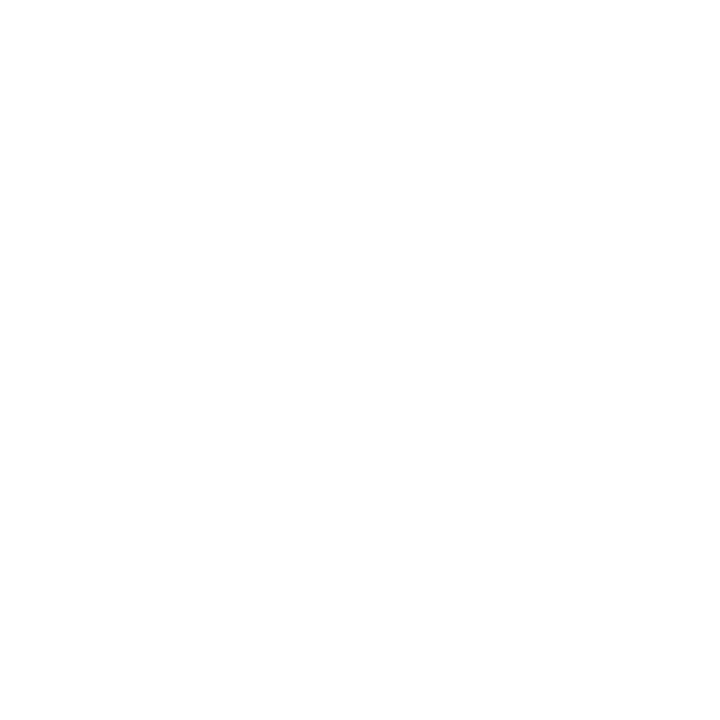

<IPython.core.display.Javascript object>


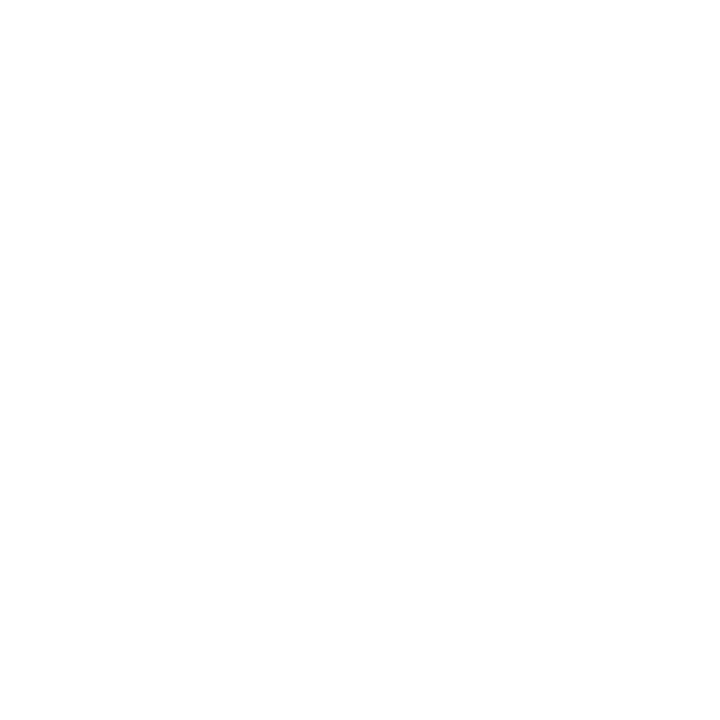

<IPython.core.display.Javascript object>


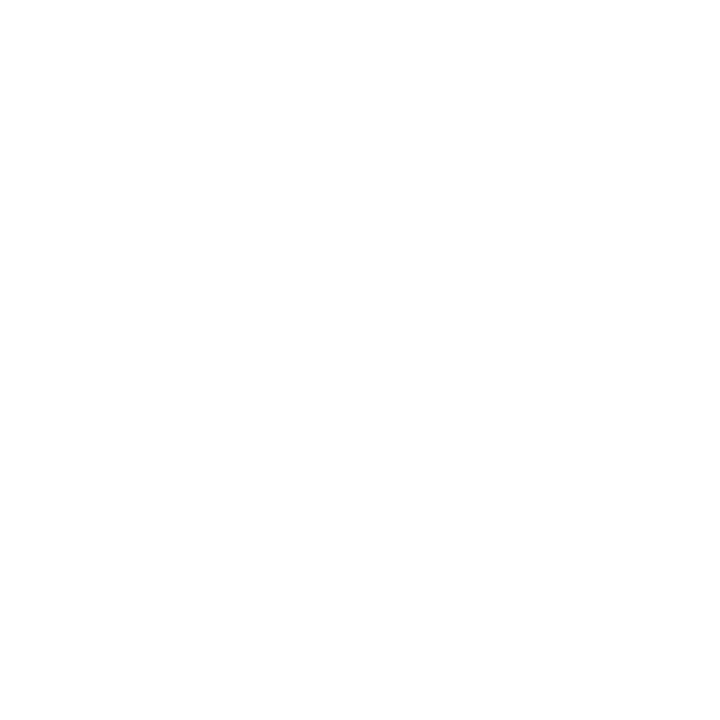

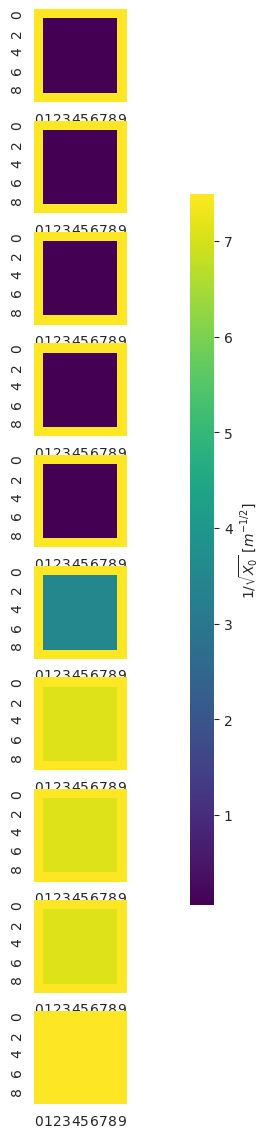

In [21]:
%matplotlib inline
# plot_pred_true_x0(pred=1/np.sqrt(volume.get_rad_cube()), true=1/np.sqrt(volume.get_rad_cube()), ColorBarLabel=r'$1/\sqrt{X0} \ [cm^{-1/2}]$')
plot_pred_true_x0(true=1/np.sqrt(volume.get_rad_cube()), ColorBarLabel=r'$1/\sqrt{X_0} \ [m^{-1/2}]$')


In the plot of the cell above the layers of the ladle can be observed, coloured depending on the X0 of the voxel material:

 - Yellow = **ladle** (steel) 
 - Light green = **liquid steel** 
 - Dark green = **Slag** 
 - Blue = **Air**

The inverse of the square root of X0 has been plotted, a value which is approximately linear to the material density. We can see that the metals have very similar X0, but they are slightly distinguishable from the slag.

## **Muon generation and propagation**


In [75]:
from tomopt.muon import MuonGenerator2016 as MuonGenerator

In [76]:
# gen = MuonGenerator.from_volume(volume, fixed_mom=5)
gen = MuonGenerator.from_volume(volume, fixed_mom=None)
gen

Muon generator: x,y range: (-0.40192377427276926, 1.4019237742727693), (-0.40192377427276926, 1.4019237742727693). Energy sampled from 0.5087855416698359-491.5127197474533 GeV.

In [77]:
from tomopt.muon import MuonBatch

In [78]:
muons = MuonBatch(gen(2000), init_z=1.8)
f'{muons.x[0]=}, {muons.y[0]=}, {muons.z[0]=}, {muons.theta[0]=}'

'muons.x[0]=tensor(1.3515), muons.y[0]=tensor(0.3732), muons.z[0]=tensor(1.8000), muons.theta[0]=tensor(1.0049)'

In [79]:
volume(mu=muons)
f'{muons.x[0]=}, {muons.y[0]=}, {muons.z[0]=}, {muons.theta[0]=}'

'muons.x[0]=tensor(3.2405), muons.y[0]=tensor(-1.7390), muons.z[0]=tensor(0.), muons.theta[0]=tensor(1.0049)'

In [91]:
hits = muons.get_hits()
hits

{'above': {'reco_xyz': tensor([[[ 1.3515,  0.3732,  1.8000],
           [ 1.3394,  0.1971,  1.6500],
           [ 1.6663,  0.0211,  1.5000]],
  
          [[ 1.0507,  1.0561,  1.8000],
           [ 1.0335,  1.1842,  1.6500],
           [ 1.0163,  1.3125,  1.5000]],
  
          [[ 0.4588, -0.0794,  1.8000],
           [ 0.4568,  0.0170,  1.6500],
           [ 0.4548,  0.1134,  1.5000]],
  
          ...,
  
          [[ 1.0491, -0.3571,  1.8000],
           [ 0.9340, -0.2336,  1.6500],
           [ 0.8188, -0.1087,  1.5000]],
  
          [[ 0.8500,  0.0330,  1.8000],
           [ 0.8995,  0.1022,  1.6500],
           [ 0.9491,  0.1714,  1.5000]],
  
          [[ 0.7559,  1.1024,  1.8000],
           [ 0.7204,  1.1909,  1.6500],
           [ 0.6849,  1.2789,  1.5000]]], grad_fn=<StackBackward0>),
  'gen_xyz': tensor([[[ 1.3515,  0.3732,  1.8000],
           [ 1.5089,  0.1972,  1.6500],
           [ 1.6663,  0.0211,  1.5000]],
  
          [[ 1.0507,  1.0561,  1.8000],
           [ 1.03

In [92]:
hits['above']['reco_xyz'].shape  # [muons, detector layer, xyz]

torch.Size([1351, 3, 3])

In [93]:
hits['above']['reco_xyz'][:, 0, 0] # [all muons, 1st layer from the top, x]
hits['above']['reco_xyz'][:, 0, 1] # [all muons, 1st layer from the top, y]

tensor([ 0.3732,  1.0561, -0.0794,  ..., -0.3571,  0.0330,  1.1024],
       grad_fn=<SelectBackward0>)

In [83]:
import matplotlib.pyplot as plt

(array([191., 197., 222., 193., 212., 223., 188., 192., 200., 182.]),
 array([-0.40052998, -0.22047411, -0.04041824,  0.13963762,  0.31969351,
         0.49974936,  0.67980522,  0.85986108,  1.03991699,  1.21997285,
         1.40002871]),
 <BarContainer object of 10 artists>)

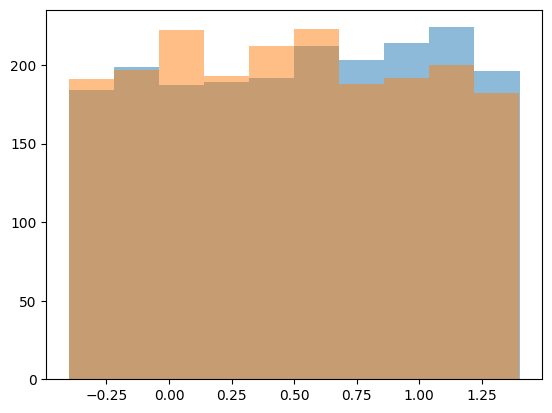

In [84]:
plt.hist(hits['above']['reco_xyz'][:, 0, 0].detach().numpy(), alpha=0.5)
plt.hist(hits['above']['reco_xyz'][:, 0, 1].detach().numpy(), alpha=0.5)

In [85]:
from tomopt.inference import ScatterBatch

In [94]:
%%time
sb = ScatterBatch(mu=muons, volume=volume)

CPU times: user 15 ms, sys: 0 ns, total: 15 ms
Wall time: 8.4 ms


In [97]:
# Efficiency of every muon in each detector panel
sb.hit_effs.shape

torch.Size([1351, 6, 1])

In [98]:
muons.mom.shape

torch.Size([1351])

In [96]:
len(sb.hit_effs[0, :, 0])
sb.hit_effs.flatten().shape

torch.Size([8106])

In [95]:
E = sb.hit_effs[:, 0, 0]
for i in range(1, len(sb.hit_effs[0, :, 0])):
    E = E + sb.hit_effs[:, i, 0]
    
E = E/len(sb.hit_effs[0, :, 0])
E = E.detach().numpy()

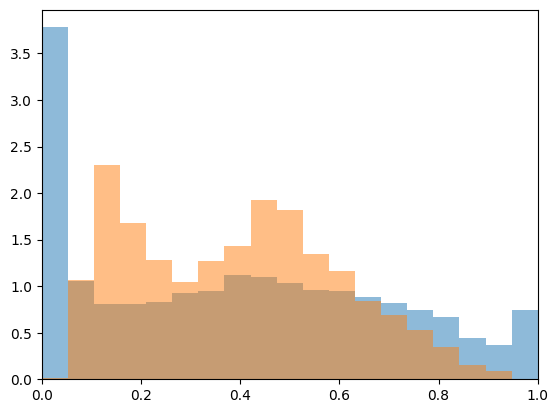

In [88]:
plt.hist(sb.hit_effs.flatten().detach().numpy(), alpha=0.5, density=True, bins=np.linspace(0,1,20))
#plt.show()

# Average efficiency of every muon in all the detector panels
plt.hist(E, alpha=0.5, density=True, bins=np.linspace(0,1,20))

plt.xlim([0, 1])
plt.show()

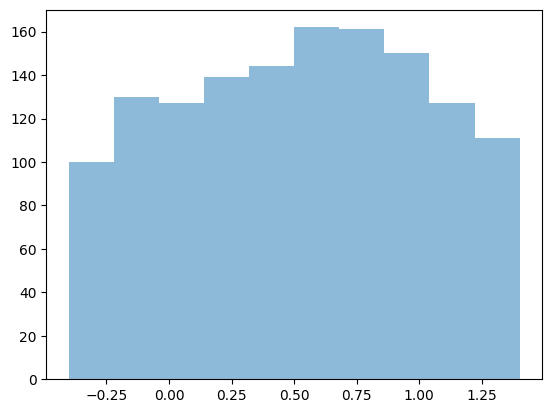

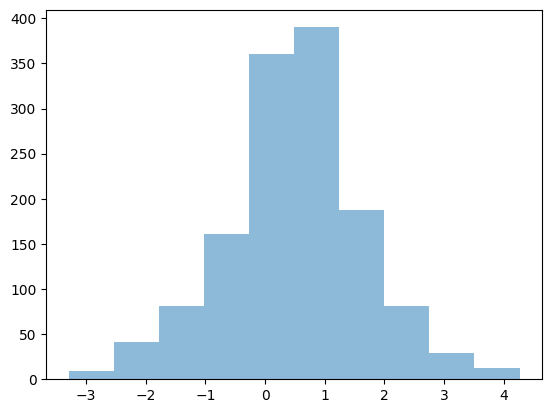

(torch.Size([1351, 3, 3]), torch.Size([1351, 3, 3]))

In [89]:
plt.hist(sb.above_gen_hits[:, 0, 0].detach().numpy(), alpha=0.5)
plt.show()
plt.hist(sb.below_gen_hits[:, 0, 0].detach().numpy(), alpha=0.5)
plt.show()

sb.above_gen_hits.shape, sb.below_gen_hits.shape

In [37]:
%%time
sb.poca_xyz, sb.poca_xyz_unc

CPU times: user 19.2 s, sys: 11.1 s, total: 30.3 s
Wall time: 16.9 s


(tensor([[ 1.0543, -0.5388,  0.6153],
         [ 0.5287,  0.0159,  1.2612],
         [ 0.4548,  0.4819,  0.8367],
         ...,
         [ 0.4682,  3.2080,  0.1880],
         [ 0.6161,  0.5261,  0.5196],
         [-0.3084,  0.7959,  1.6794]], grad_fn=<AddBackward0>),
 tensor([[1.8669e-01, 2.6426e-01, 4.0426e-01],
         [4.1998e-04, 8.2912e-04, 1.1527e-03],
         [3.4041e-05, 7.0053e-04, 8.5765e-04],
         ...,
         [4.6639e-02, 1.8229e-01, 1.5669e-01],
         [5.8238e-04, 1.5300e-04, 1.4477e-03],
         [4.1889e-02, 3.4353e-01, 9.8141e-01]], grad_fn=<SqrtBackward0>))

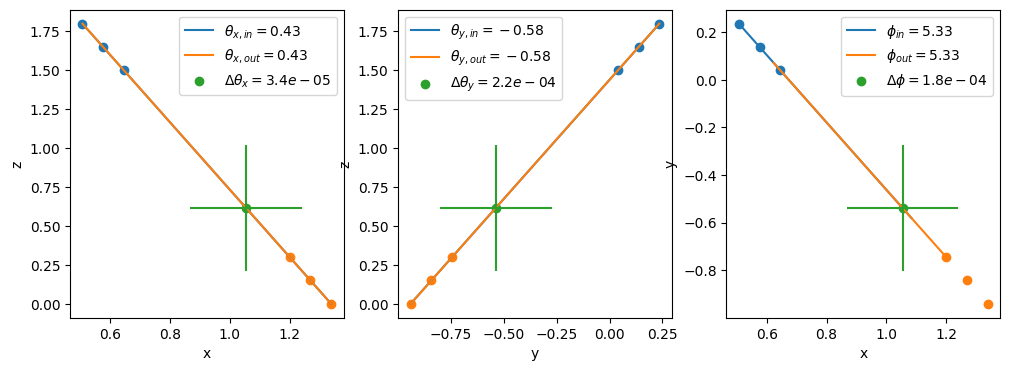

In [38]:
sb.plot_scatter(idx=0)

# Run multiple simulations and get estimator (NN) inputs (per muon basis hits) and inference objective (voxel-wise X0)

### Generation

In [39]:
GeneratedMuons = 10000
muons = MuonBatch(gen(10000), init_z=1.8)
f'{muons.x[0]=}, {muons.y[0]=}, {muons.z[0]=}, {muons.theta[0]=}'

'muons.x[0]=tensor(1.3219), muons.y[0]=tensor(-0.0950), muons.z[0]=tensor(1.8000), muons.theta[0]=tensor(0.3879)'

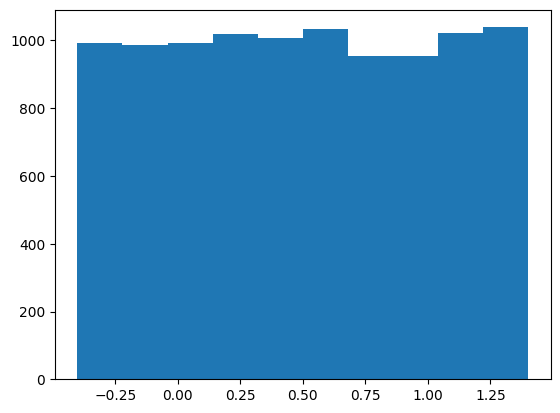

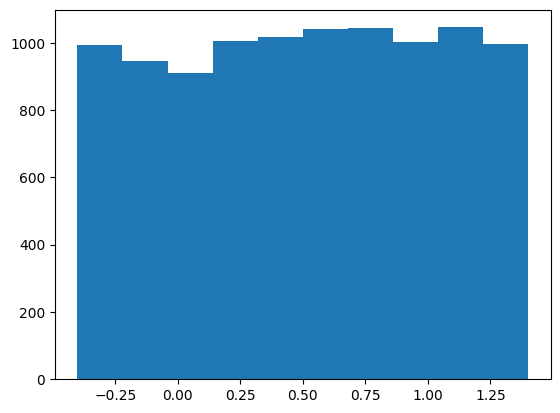

tensor(-0.4013)

In [40]:
plt.hist(muons.x)
plt.show()

plt.hist(muons.y)
plt.show()

min(muons.x)

In [277]:
from tomopt.tools import prog_bar

#TrueSteelLevels = np.zeros(len(trn_passives.passives))
#TrueSteelLevels[:] = np.nan

#Poca_z_means = np.zeros(len(trn_passives.passives))
#Poca_z_means[:] = np.nan

# Muons per volume
GeneratedMuons = 10

print("Generating " + str(len(trn_passives.passives)) + " simulations")

for i in range(0, len(trn_passives.passives)):
    
    #pint(i)
    
    prog_bar(percent=100.0*(i+1)/len(trn_passives.passives))
    
    SelectedVolume = i
    f,t = trn_passives.passives[SelectedVolume]
    volume.load_rad_length(f, t)
    
    # plot_pred_true_x0(1/np.sqrt(volume.get_rad_cube()), 1/np.sqrt(volume.get_rad_cube()))
    
    # Generate
    muons = MuonBatch(gen(GeneratedMuons), init_z=1.8)
    f'{muons.x[0]=}, {muons.y[0]=}, {muons.z[0]=}, {muons.theta[0]=}'

    # Propagate
    volume(mu=muons)
    f'{muons.x[0]=}, {muons.y[0]=}, {muons.z[0]=}, {muons.theta[0]=}'
    
    #print(muons.mom.shape)

    # Inputs
    X_tensor_OneSim = torch.cat((muons.get_hits()['above']['reco_xyz'][:, 0, 0:2],  # [detector above] [all muons, 1st layer from the top, x-y-z]
                          muons.get_hits()['above']['reco_xyz'][:, 2, 0:2], # [detector above] [all muons, 3rd layer from the top, x-y]
                          muons.get_hits()['below']['reco_xyz'][:, 0, 0:2], # [detector below] [all muons, 1st layer from the top, x-y]
                          muons.get_hits()['below']['reco_xyz'][:, 2, 0:2], # [detector below] [all muons, 3rd layer from the top, x-y]
                         ), 1)
    
    X_tensor_OneSim = torch.cat([X_tensor_OneSim, muons.mom.unsqueeze(0).transpose(0, 1)], dim=1)
    
    if i==0:
        X_tensor = X_tensor_OneSim
    else:
        X_tensor = torch.cat((X_tensor, X_tensor_OneSim), 0)
    
    
    # Outputs
    #x0 = volume.get_rad_cube()
    x0 = 1/np.sqrt(volume.get_rad_cube())
    y_tensor_OneSim = x0.flatten()
    
    #for j in range(0, X_tensor_OneSim.shape[0]):
    #    y_tensor_OneSim = torch.cat((y_tensor_OneSim.unsqueeze(0).transpose(0, 1), y_tensor_OneSim.unsqueeze(0).transpose(0, 1)), 1)

    y_tensor_OneSim = y_tensor_OneSim.repeat(X_tensor_OneSim.shape[0], 1)

    if i==0:
        #y_tensor = y_tensor_OneSim.unsqueeze(0).transpose(0, 1)
        y_tensor = y_tensor_OneSim
    else:
        #y_tensor = torch.cat((y_tensor, y_tensor_OneSim.unsqueeze(0).transpose(0, 1)), 1)
        y_tensor = torch.cat((y_tensor, y_tensor_OneSim), 0)
    
    #sb = ScatterBatch(mu=muons, volume=volume)
    #sb.poca_xyz, sb.poca_xyz_unc
    


Generating 800 simulations
Completed: [==========================================================================================] 100%

In [279]:
X_tensor.shape

torch.Size([8000, 9])

In [280]:
y_tensor.shape

torch.Size([8000, 1000])

In [281]:
len(trn_passives.passives)*GeneratedMuons

8000

In [282]:
X_tensor[0,:]

tensor([ 0.3919,  0.4355,  0.3189,  0.4559,  0.0474,  0.5338, -0.0041,  0.5450,
         0.4977], grad_fn=<SliceBackward0>)

(array([7.751e+03, 1.850e+02, 3.300e+01, 1.300e+01, 1.100e+01, 2.000e+00,
        2.000e+00, 2.000e+00, 0.000e+00, 1.000e+00]),
 array([ 0.49769372,  5.83724403, 11.17679405, 16.51634407, 21.85589409,
        27.19544411, 32.53499603, 37.87454605, 43.21409607, 48.55364609,
        53.89319611]),
 <BarContainer object of 10 artists>)

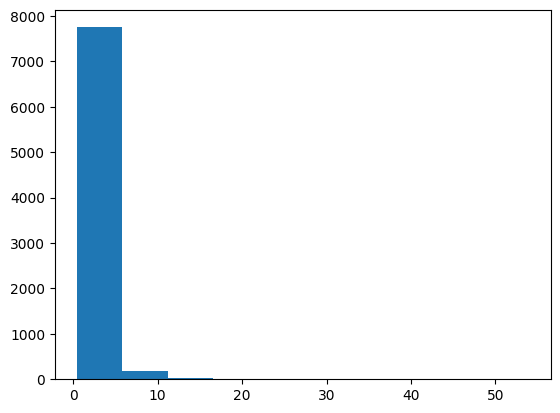

In [283]:
# Momentum
plt.hist(X_tensor[:,8].detach().numpy())

(array([1792000.,       0.,       0.,       0.,  512000.,       0.,
              0.,       0.,       0., 5696000.]),
 array([0.05736337, 0.80073798, 1.54411256, 2.28748727, 3.03086185,
        3.77423644, 4.51761103, 5.26098537, 6.0043602 , 6.74773455,
        7.49110937]),
 <BarContainer object of 10 artists>)

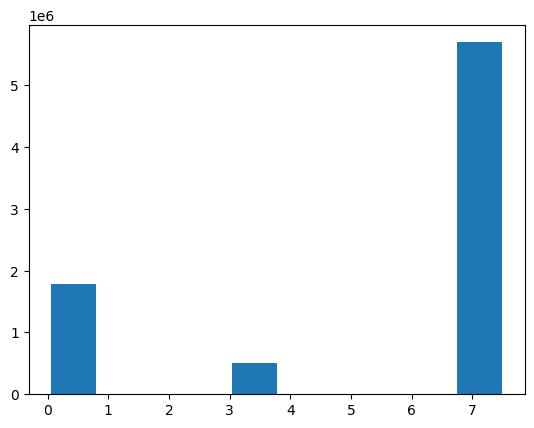

In [284]:
# 1/sqrt(x0)
plt.hist(y_tensor.detach().numpy().flatten())

In [289]:
import torch
import torch.nn as nn
import torch.optim as optim

# To save history evolution
train_losses = []
val_losses = []

# Make sure input tensors are marked as constants:
X_tensor = X_tensor.detach()
y_tensor = y_tensor.detach()

# Set random seed for reproducibility
torch.manual_seed(42)

## Simulated dataset: 500 samples, 13 inputs → 1000 outputs
#X_tensor = torch.randn(500, 13)
#y_tensor = torch.randn(500, 1000)

# Optional: Normalize data (standardization)
X_mean, X_std = X_tensor.mean(0, keepdim=True), X_tensor.std(0, keepdim=True)
y_mean, y_std = y_tensor.mean(0, keepdim=True), y_tensor.std(0, keepdim=True)

X_tensor = (X_tensor - X_mean) / (X_std + 1e-8)
y_tensor = (y_tensor - y_mean) / (y_std + 1e-8)

# Train/test split using torch
n_samples = X_tensor.size(0)
perm = torch.randperm(n_samples)
split_idx = int(0.8 * n_samples)
train_idx, test_idx = perm[:split_idx], perm[split_idx:]

X_train, y_train = X_tensor[train_idx], y_tensor[train_idx]
X_test, y_test = X_tensor[test_idx], y_tensor[test_idx]

# Define the model
class RegressionNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(X_train.shape[1], 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 1000)
        )

    def forward(self, x):
        return self.net(x)

model = RegressionNN()

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training loop
EPOCHS = 20
EACH = EPOCHS/10
for epoch in range(EPOCHS):
    model.train()
    preds = model(X_train)
    loss = criterion(preds, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % EACH == 0:
    #if (epoch + 1) % 10 == 0:

        train_losses.append(loss.item())  # 📌 Save training loss

        # Validation    
        model.eval()
        with torch.no_grad():
            val_preds = model(X_test)
            val_loss = criterion(val_preds, y_test)
        
        val_losses.append(val_loss.item())  # 📌 Save validation loss
        print(f"Epoch {epoch+1:>2}: Train Loss = {loss.item():.4f} | Val Loss = {val_loss.item():.4f}")


Epoch  2: Train Loss = 0.5212 | Val Loss = 0.5102
Epoch  4: Train Loss = 0.5169 | Val Loss = 0.5078
Epoch  6: Train Loss = 0.5154 | Val Loss = 0.5069
Epoch  8: Train Loss = 0.5147 | Val Loss = 0.5064
Epoch 10: Train Loss = 0.5143 | Val Loss = 0.5062
Epoch 12: Train Loss = 0.5140 | Val Loss = 0.5060
Epoch 14: Train Loss = 0.5138 | Val Loss = 0.5059
Epoch 16: Train Loss = 0.5137 | Val Loss = 0.5058
Epoch 18: Train Loss = 0.5135 | Val Loss = 0.5058
Epoch 20: Train Loss = 0.5134 | Val Loss = 0.5058


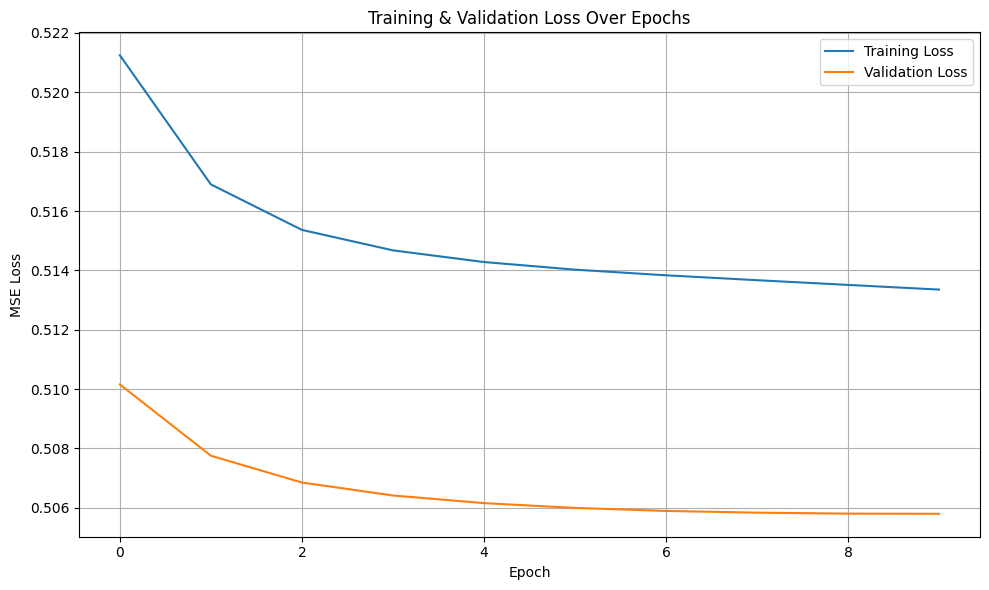

In [290]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training & Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [309]:
y_test.flatten().shape

torch.Size([1600000])

In [325]:
voxel_index = 600  # Can change to any voxel index [0, 999]

predicted_values = val_preds[:, voxel_index].cpu().numpy()
true_values = y_test[:, voxel_index].cpu().numpy()

In [326]:
true_values

array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)

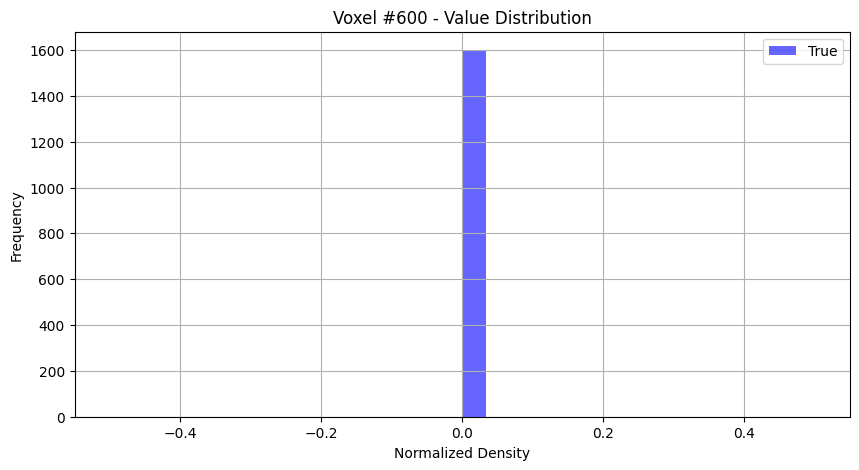

In [327]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
#plt.hist(predicted_values, bins=30, alpha=0.6, label='Predicted', color='orange')
plt.hist(true_values, bins=30, alpha=0.6, label='True', color='blue')
#plt.hist(y_test.flatten(), bins=21, alpha=0.6, label='True', color='blue')
plt.title(f'Voxel #{voxel_index} - Value Distribution')
plt.xlabel('Normalized Density')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()
